<a href="https://colab.research.google.com/github/RexBil/Driver-Drowsiness-Detection/blob/main/Driver_Drowsiness_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from google.colab import drive
import matplotlib.image as mpimg
import numpy as np # Added numpy import

# Mount Google Drive to access your folders
drive.mount('/content/drive')

# --- CONFIGURATION ---
# Replace with the path to your "combined" main folder [cite: 157, 164]
DATASET_PATH = '/content/drive/MyDrive/train'
IMG_SIZE = 224 # [cite: 60]
BATCH_SIZE = 32

# --- DATA PREPROCESSING
# Resizing, Normalizing, and Augmentation [cite: 60, 61, 62]
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Automatically creates training/validation split [cite: 53]
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Print class indices to verify folder mapping [cite: 132]
print(f"Class Mapping: {train_data.class_indices}")

# --- MODEL BUILDING
# Using MobileNetV2 as requested [cite: 69, 137]
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Freeze base layers [cite: 82]

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x) # 4 output classes [cite: 98]

model = Model(inputs=base_model.input, outputs=output)

# --- TRAINING
# Using Adam optimizer and cross-entropy loss [cite: 85, 86, 139]
model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10 # Monitors validation accuracy and loss [cite: 87]
)

# --- EVALUATION & RESULT
# Mapping 4 classes to the 3-level Fatigue Logic [cite: 104-109]
def predict_and_show(image_path):
    # 1. Load and Preprocess the image [cite: 60, 61]
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)

    # 2. Get Prediction
    preds = model.predict(img_array)
    class_idx = tf.argmax(preds[0]).numpy()
    confidence = np.max(preds[0]) * 100

    # 3. Map to Folder Name and Fatigue Stage [cite: 104, 105]
    labels = {v: k for k, v in train_data.class_indices.items()}
    predicted_folder = labels[class_idx]

    mapping = {
        'Open': 'Level 0: Alert',
        'no_yawn': 'Level 0: Alert',
        'yawn': 'Level 1: Mild Fatigue',
        'Closed': 'Level 2: Severe Fatigue'
    }

    stage = mapping.get(predicted_folder, "Unknown")

    # 4. Display the Image and Results [cite: 146]
    plt.imshow(mpimg.imread(image_path))
    plt.title(f"Prediction: {predicted_folder}\nStage: {stage}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    return stage

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2325 images belonging to 4 classes.
Found 579 images belonging to 4 classes.
Class Mapping: {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}
Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 70s 837ms/step - accuracy: 0.7751 - loss: 0.4618 - val_accuracy: 0.7720 - val_loss: 0.3889
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 646ms/step - accuracy: 0.8370 - loss: 0.3217 - val_accuracy: 0.8048 - val_loss: 0.3836
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 641ms/step - accuracy: 0.8701 - loss: 0.2699 - val_accuracy: 0.7599 - val_loss: 0.3826
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 46s 631ms/step - accuracy: 0.8753 - loss: 0.2575 - val_accuracy: 0.7962 - val_loss: 0.4153
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 46s 628ms/step - accuracy: 0.8839 - loss: 0.2340 - val_accuracy: 0.8066 - val_loss: 0.3888
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 645ms/step - accuracy: 0.8951 - loss

In [11]:
print(train_data.class_indices)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


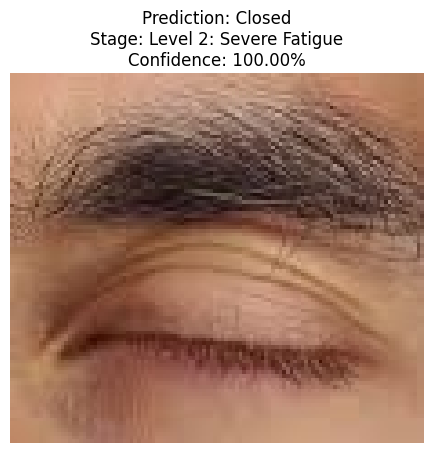

'Level 2: Severe Fatigue'

In [24]:
# Test it
test_path = '/content/_6.jpg'
predict_and_show(test_path)